In [5]:
import sys
from pathlib import Path
import pkgutil

# Current notebook directory (e.g. .../job-intelligence-engine/notebooks/Evaluation_test)
nb_dir = Path().resolve()

# Go up TWO levels: Evaluation_test -> notebooks -> job-intelligence-engine
project_root = nb_dir.parents[1]      # THIS is the repo root
src_root = project_root / "src"       # .../job-intelligence-engine/src

print("Notebook dir:", nb_dir)
print("Project root:", project_root)
print("SRC root:", src_root)

# Add src to PYTHONPATH
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

# Test visibility
print(
    "job_intel visible?",
    any(m.name == "job_intel" for m in pkgutil.iter_modules([str(src_root)])),
)


Notebook dir: /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/notebooks/Evaluation_test
Project root: /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine
SRC root: /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/src
job_intel visible? True


Loading raw jobs ...
Raw combined shape: (6162, 16)
Replaced -1 with NAs
Added location features.
Simplified ownership.
Converted year to integer.
Dropped uneccesary features (Nas and extremely complex) - Easy Apply, Competitors, Company Name and Revenue.
Added job_description_clean.
Added title/seniority/family features (using cleaned description).
Added domain from lookup (missing=0).
Added salary features from 'Salary Estimate'.
Added skill flag features.
Dropping columns: ['Job Title', 'job_title_for_skills', 'job_title_raw', 'Salary Estimate', 'seniority_roman', 'seniority_title', 'seniority_description', 'state_hq']


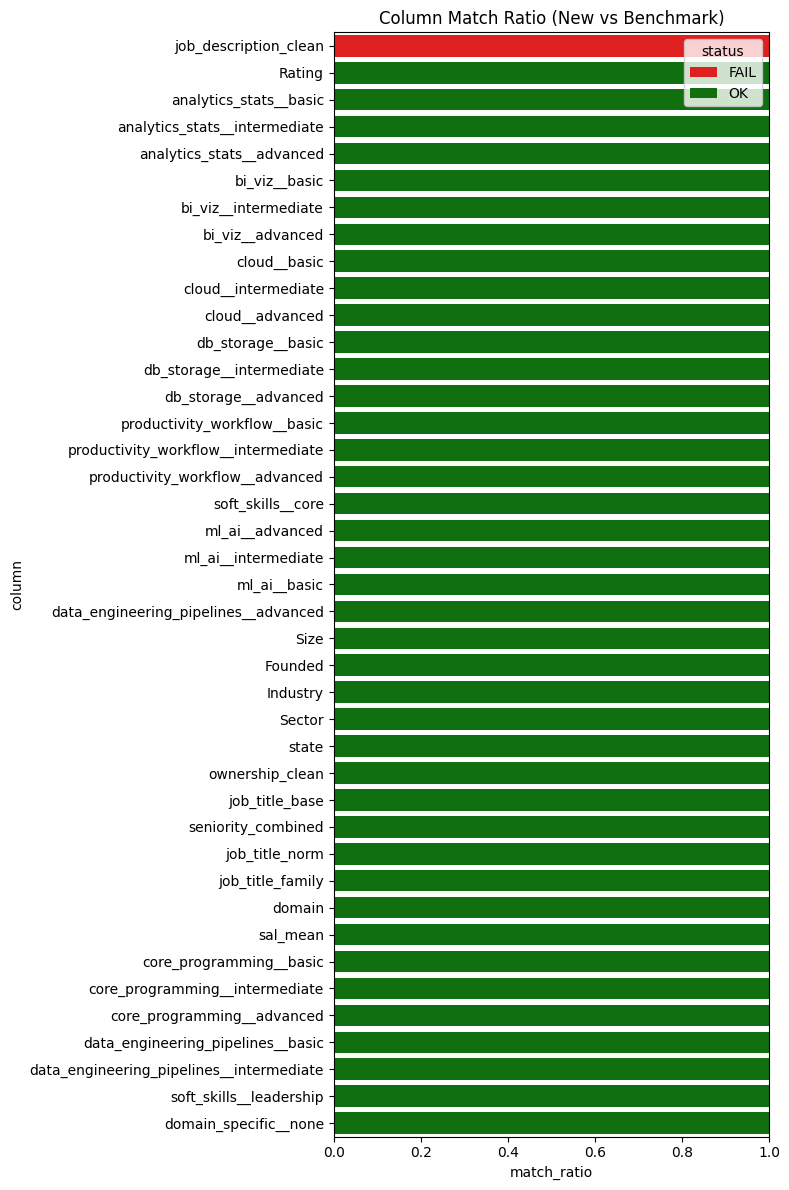


=== BENCHMARK SUMMARY ===
                                  column  match_ratio  mismatches status
                                  Rating     1.000000           0     OK
                                    Size     1.000000           0     OK
                                 Founded     1.000000           0     OK
                                Industry     1.000000           0     OK
                                  Sector     1.000000           0     OK
                                   state     1.000000           0     OK
                         ownership_clean     1.000000           0     OK
                   job_description_clean     0.999838           1   FAIL
                          job_title_base     1.000000           0     OK
                      seniority_combined     1.000000           0     OK
                          job_title_norm     1.000000           0     OK
                        job_title_family     1.000000           0     OK
                        

,column,match_ratio,mismatches,status
0,Rating,1.0,0,OK
1,Size,1.0,0,OK
2,Founded,1.0,0,OK
3,Industry,1.0,0,OK
4,Sector,1.0,0,OK


In [7]:
# --- Chapter 0 Data Benchmark Test ---
from job_intel.evaluation.build_base_dataset_benchmark import run_benchmark

benchmark_results = run_benchmark(show_plots=True)

print("\n=== Benchmark Results (Top Rows) ===")
benchmark_results.head()


In [ ]:
# --- Salary Model Evaluation Test ---

import pandas as pd
from pathlib import Path

import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))
project_root

from src.job_intel.evaluation.salary_model_eval import evaluate_salary_model
from src.job_intel.config import CH1_PROCESSED_SALARY_MODEL_PCA_DF

# Load processed dataset used for salary model
df = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_PCA_DF)

# Split into features + response
response = df["sal_mean"].copy()
features = df[[
    'size_code', 'sector_code', 'state_code','ownership_code',
    'seniority_code', 'title_rich_code', 
    'skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC4', 'skill_PC5', 
    'skill_PC6', 'skill_PC7', 'skill_PC8', 'skill_PC9', 'skill_PC10'
]].copy()

# Ensure categorical types
cat_cols = ['size_code','sector_code','state_code','ownership_code',
            'seniority_code','title_rich_code']
features[cat_cols] = features[cat_cols].astype('category')

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features, response, test_size=0.20, random_state=101
)

# Evaluate
metrics = evaluate_salary_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=features.columns,   # for plots
    show_plots=True
)

print("\n=== Salary Model Metrics ===")
for k, v in metrics.items():
    print(f"{k:12} : {v:.4f}")
